# 04 – Solubility (logS)  
## Phase 4 de la pipeline ADMET : prédiction de la solubilité aqueuse

**Contexte.**  
Après le Virtual Screening, l’évaluation hERG et l’inhibition CYP450, l’étape suivante consiste à vérifier que nos hits sont suffisamment solubles dans l’eau pour être développés (ou reformulés) ; la solubilité est un facteur critique pour la biodisponibilité orale et la réussite in vivo.

**Objectif de ce notebook.**

1. Charger le dataset **AqSolDB** depuis la librairie **TDC**.  
2. Nettoyer les SMILES et générer des empreintes **ECFP4** (± descripteurs Lipinski).  
3. Entraîner rapidement plusieurs modèles (SGD, LogReg, SVM, Random Forest) avec le même wrapper `train_all_models` utilisé dans les notebooks hERG et CYP450.  
4. Comparer les performances (R² ou ROC‑AUC / PR‑AUC si on convertit en classe binaire).  
5. Visualiser les résidus (régression) ou les distributions de probabilité (classification).  
6. Dégager les **features** les plus influentes (importance RF) et proposer des pistes d’amélioration (fingerprints alternatifs, algos Boosting, PCA…).




In [1]:
import sys
# Ajoute le parent du dossier notebooks (le root de ton projet) au PYTHONPATH
sys.path.append('..')


In [2]:
# %% [code] — Imports & style global
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from tdc.single_pred import ADME

from src.preprocessing import (
    process_smiles,
    compute_ecfp4,
    setup_visualization_style,
    #calculate_ro5_descriptors   
)
from src.modeling import (
    train_all_models,
    evaluate_model,
)

# Style visuel commun à tous les notebooks ADMET
setup_visualization_style()

# Dossiers de travail
DATA_DIR = Path("artifacts")
FIG_DIR  = Path("fig")
FIG_DIR.mkdir(exist_ok=True)

print("=== Solubility pipeline – initialisation OK ===")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found

=== Solubility pipeline – initialisation OK ===


## 1. Chargement du dataset AqSolDB

Nous utilisons le jeu **Aqueous Solubility (AqSolDB)** distribué dans `TDC`.  
Le split par défaut (`get_split()`) propose :

* **train scaffold** – 80 %  
* **test scaffold** – 20 %

Nous vérifions la taille de chaque split et affichons un aperçu des premières lignes.


In [3]:
# %% [code] — Chargement + aperçu
print("▶️  Téléchargement du dataset AqSolDB depuis TDC ...")
aqsol = ADME(name="Solubility_AqSolDB")

# Nom et description rapides
print(f"Dataset       : {aqsol.name}")
print(f"Target column : {aqsol.label_name}\n")

# Split officiel TDC
split = aqsol.get_split()
train_df, test_df = split["train"], split["test"]

print(f"N_train = {len(train_df):,} molécules")
print(f"N_test  = {len(test_df):,} molécules")

# Aperçu
print("\nAperçu train :")
display(train_df.head())
print("\nAperçu test  :")
display(test_df.head())


Found local copy...
Loading...
Done!


▶️  Téléchargement du dataset AqSolDB depuis TDC ...
Dataset       : solubility_aqsoldb
Target column : None

N_train = 6,988 molécules
N_test  = 1,996 molécules

Aperçu train :


,Drug_ID,Drug,Y
0,Benzo[cd]indol-2(1H)-one,O=C1Nc2cccc3cccc1c23,-3.254767
1,4-chlorobenzaldehyde,O=Cc1ccc(Cl)cc1,-2.177078
2,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,c1cc(N(CC2CO2)CC2CO2)ccc1Cc1ccc(N(CC2CO2)CC2CO...,-4.662065
3,vinyltoluene,C=Cc1cccc(C)c1,-3.123150
4,3-(3-ethylcyclopentyl)propanoic acid,CCC1CCC(CCC(=O)O)C1,-3.286116



Aperçu test  :


,Drug_ID,Drug,Y
0,"2-ethyl-9,10-dihydroanthracene-9,10-dione",CCc1ccc2c(c1)C(=O)c1ccccc1C2=O,-5.984242
1,Digoxin,CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,-4.160000
2,diphenic acid,O=C(O)c1ccccc1-c1ccccc1C(=O)O,-2.283900
3,pentachlorobutadiene,ClC(Cl)=CC(Cl)=C(Cl)Cl,-4.230000
4,trimethyl phosphate,COP(=O)(OC)OC,0.552600


## 2. Featurisation avancée  
Nous générons trois jeux d’empreintes :

* **ECFP4** (2048 bits)  
* **ECFP6** (2048 bits)  
* **MACCS‑166**  

et, en option, un vecteur de descripteurs physico‑chimiques RDKit (logP, TPSA, etc.).  
Quatre « feature sets » seront comparés :  

1. `FP_ECFP4`  
2. `FP_ECFP4+DESC` (ECFP4 concat descripteurs)  
3. `FP_CONCAT` = ECFP4 | ECFP6 | MACCS  
4. `DESC_ONLY`  

## 3. Entraînement & comparaison des représentations
Nous entraînons le même panel de modèles (`train_all_models`) sur chaque jeu de features et comparons les métriques (R² pour régression).


Found local copy...
Loading...
Done!


▶️  Featurisation train / test …

=== Feature set : FP_ECFP4 (2048 dims) ===
→ SGD
Metrics for Pipeline:
    accuracy: 0.811
   precision: 0.848
      recall: 0.890
          f1: 0.868
     roc_auc: 0.799
      pr_auc: 0.867
         mcc: 0.534


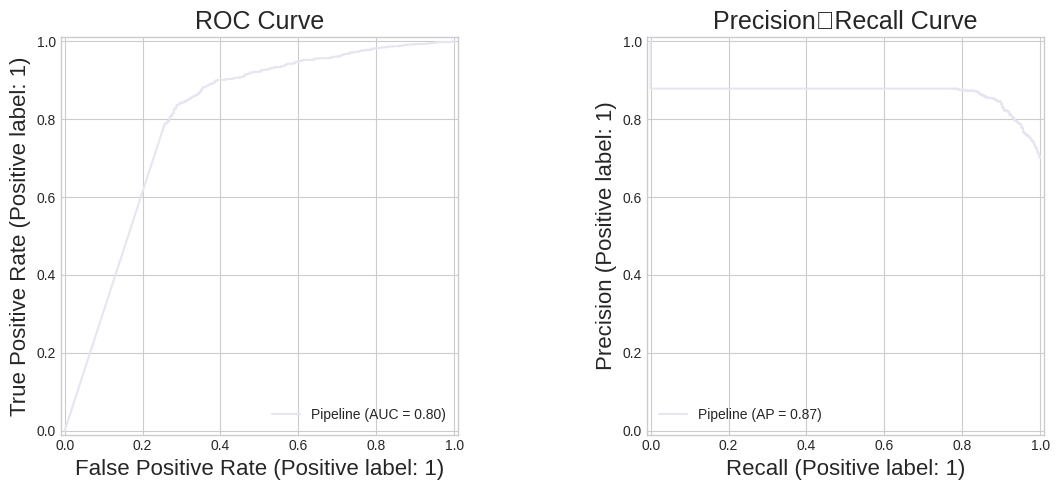

→ LogReg
Metrics for Pipeline:
    accuracy: 0.802
   precision: 0.877
      recall: 0.834
          f1: 0.855
     roc_auc: 0.830
      pr_auc: 0.898
         mcc: 0.543


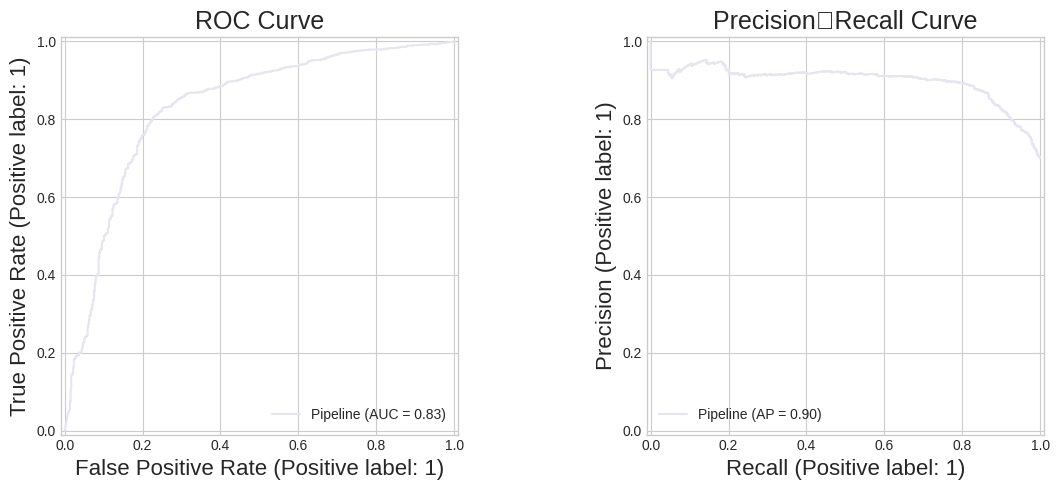

→ RF
Metrics for RandomForestClassifier:
    accuracy: 0.849
   precision: 0.851
      recall: 0.950
          f1: 0.898
     roc_auc: 0.911
      pr_auc: 0.953
         mcc: 0.622


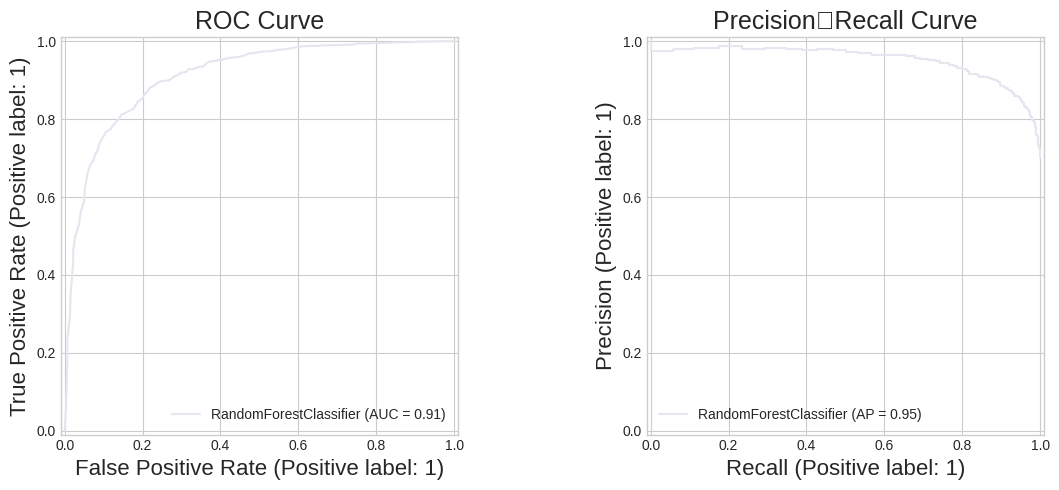


Feature importances:


1143    1.401476e-02
807     1.128206e-02
1683    9.783947e-03
561     9.260415e-03
366     8.758419e-03
            ...     
1397    5.742497e-06
1201    2.061758e-06
1293    1.995028e-06
1108    1.781527e-06
1553    7.333855e-08
Length: 2048, dtype: float64


=== Feature set : FP_ECFP4+DESC (2055 dims) ===
→ SGD
Metrics for Pipeline:
    accuracy: 0.816
   precision: 0.847
      recall: 0.900
          f1: 0.873
     roc_auc: 0.803
      pr_auc: 0.867
         mcc: 0.544


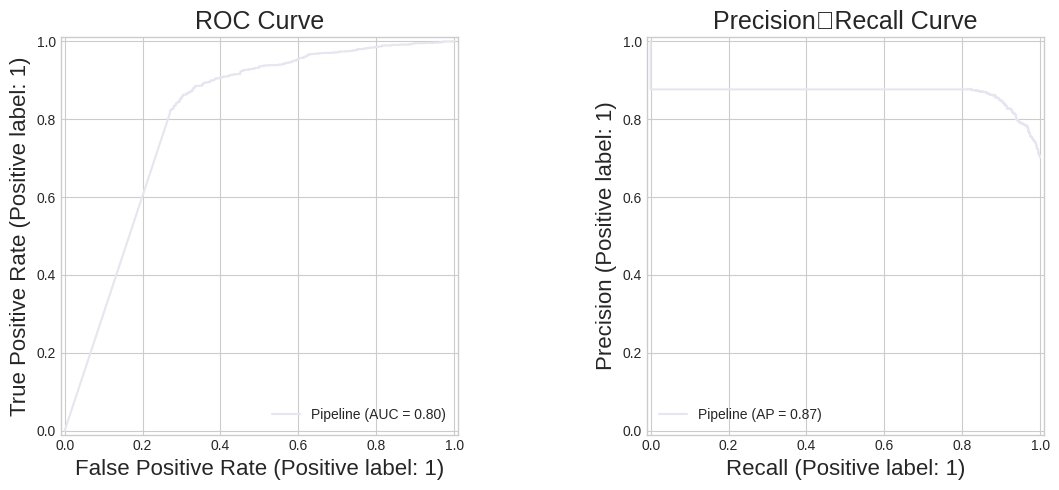

→ LogReg
Metrics for Pipeline:
    accuracy: 0.812
   precision: 0.883
      recall: 0.844
          f1: 0.863
     roc_auc: 0.845
      pr_auc: 0.907
         mcc: 0.565


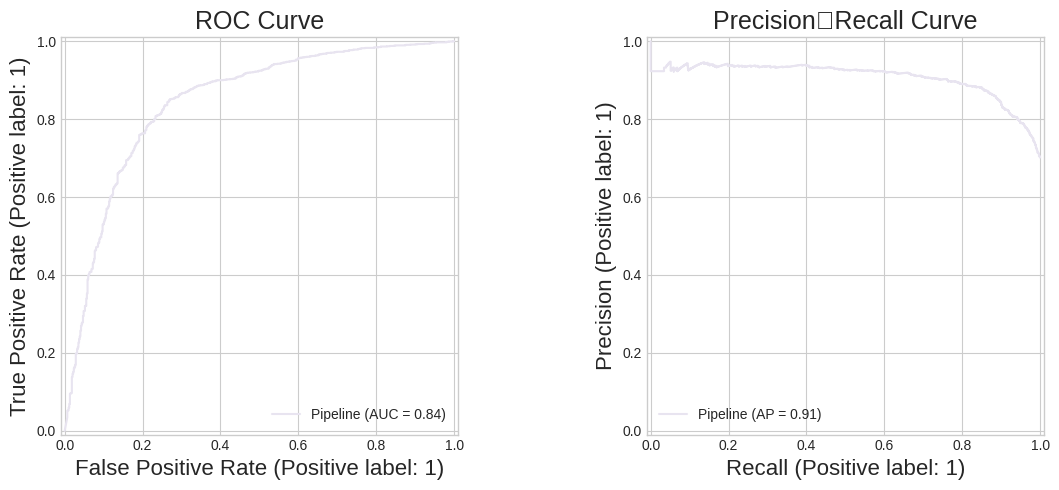

→ RF
Metrics for RandomForestClassifier:
    accuracy: 0.894
   precision: 0.903
      recall: 0.951
          f1: 0.926
     roc_auc: 0.954
      pr_auc: 0.978
         mcc: 0.740


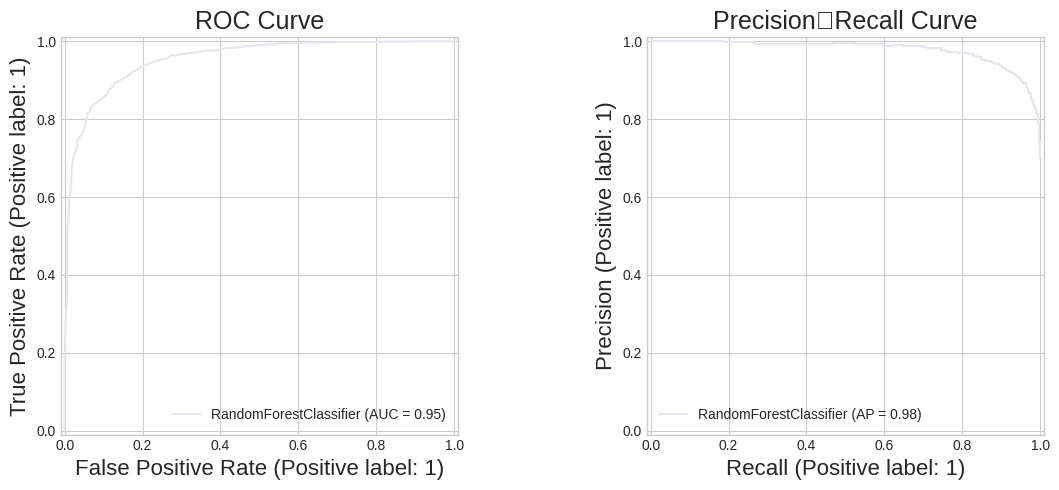


Feature importances:


logP     1.230332e-01
MolWt    6.659403e-02
Rings    2.610892e-02
TPSA     2.413868e-02
RotB     2.284427e-02
             ...     
1596     2.958497e-07
518      2.327815e-07
1519     1.687967e-07
111      1.354149e-07
830      0.000000e+00
Length: 2055, dtype: float64


*** Résultats FP_ECFP4 (seuil logS -4.0) ***


,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc
SGD,0.811,0.848,0.890,0.868,0.799,0.867,0.534
LogReg,0.802,0.877,0.834,0.855,0.830,0.898,0.543
RF,0.849,0.851,0.950,0.898,0.911,0.953,0.622



*** Résultats FP_ECFP4+DESC (seuil logS -4.0) ***


,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc
SGD,0.816,0.847,0.900,0.873,0.803,0.867,0.544
LogReg,0.812,0.883,0.844,0.863,0.845,0.907,0.565
RF,0.894,0.903,0.951,0.926,0.954,0.978,0.740


In [4]:
# %% [code] — Pipeline classification (logS binaire) avec ton train_all_models
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

from tdc.single_pred import ADME
from src.preprocessing import (
    process_smiles, compute_ecfp4, create_molecule_from_smiles
)
from src.modeling import train_all_models, evaluate_model

# ------------------------------------------------------------------ #
# 0) Paramètres
THR_LOGS   = -4.0           # seuil logS pour soluble / insoluble
FEATURES_TO_RUN = ["FP_ECFP4", "FP_ECFP4+DESC"]   # ajoute FP_CONCAT plus tard

# ------------------------------------------------------------------ #
# 1) Dataset
aqsol = ADME(name="solubility_aqsoldb")
train_df, test_df = aqsol.get_split()["train"], aqsol.get_split()["test"]

# ------------------------------------------------------------------ #
# 2) Featurisation helpers
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, GraphDescriptors
RDKIT_DESCRIPTORS = {
    'MolWt'   : Descriptors.MolWt,
    'logP'    : Crippen.MolLogP,
    'TPSA'    : rdMolDescriptors.CalcTPSA,
    'HBD'     : Lipinski.NumHDonors,
    'HBA'     : Lipinski.NumHAcceptors,
    'RotB'    : Lipinski.NumRotatableBonds,
    'Rings'   : rdMolDescriptors.CalcNumRings,
}

def rdkit_desc_vec(smi):
    mol = create_molecule_from_smiles(smi)
    if mol is None: return None
    return [f(mol) for f in RDKIT_DESCRIPTORS.values()]

def featurize(df, smiles_col="Drug"):
    df = df.copy()
    df["smiles_clean"] = df[smiles_col].map(process_smiles)
    df.dropna(subset=["smiles_clean"], inplace=True)

    # --- Empreinte ECFP4 ---
    X_ecfp4 = pd.DataFrame(
        df["smiles_clean"].map(compute_ecfp4).tolist(),
        index=df.index
    )

    # --- Descripteurs RDKit ---
    desc_df = pd.DataFrame(
        df["smiles_clean"].map(rdkit_desc_vec).tolist(),
        columns=list(RDKIT_DESCRIPTORS.keys()),
        index=df.index
    )

    feats = {
        "FP_ECFP4"      : X_ecfp4.copy(),
        "FP_ECFP4+DESC" : pd.concat([X_ecfp4, desc_df], axis=1)
    }

    for k in feats:
        feats[k].columns = feats[k].columns.astype(str)   # <- ICI

    y_bin = (df["Y"] >= THR_LOGS).astype(int)
    return feats, y_bin


print("▶️  Featurisation train / test …")
Xtrain_dict, y_train = featurize(train_df)
Xtest_dict,  y_test  = featurize(test_df)

# ------------------------------------------------------------------ #
# 4) Boucle d’entraînement + évaluation
global_results = {}
for fs_name in FEATURES_TO_RUN:
    X_tr, X_te = Xtrain_dict[fs_name], Xtest_dict[fs_name]
    print(f"\n=== Feature set : {fs_name} ({X_tr.shape[1]} dims) ===")

    models = train_all_models(X_tr, y_train)   # tes wrappers
    # On retire la clé 'SVM' bidon
    models = {k:v for k,v in models.items() if k != "SVM"}

    res = {}
    for mname, mdl in models.items():
        print(f"→ {mname}")
        res[mname] = evaluate_model(
            mdl, X_te, y_test,
            feature_names=X_tr.columns,
            plot_curves=True
        )
    global_results[fs_name] = pd.DataFrame(res).T

# ------------------------------------------------------------------ #
# 5) Tableau récapitulatif
for fs, df in global_results.items():
    print(f"\n*** Résultats {fs} (seuil logS {THR_LOGS}) ***")
    display(df.round(3))


Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best params : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Metrics for RandomForestClassifier:
    accuracy: 0.895
   precision: 0.905
      recall: 0.950
          f1: 0.927
     roc_auc: 0.955
      pr_auc: 0.980
         mcc: 0.744


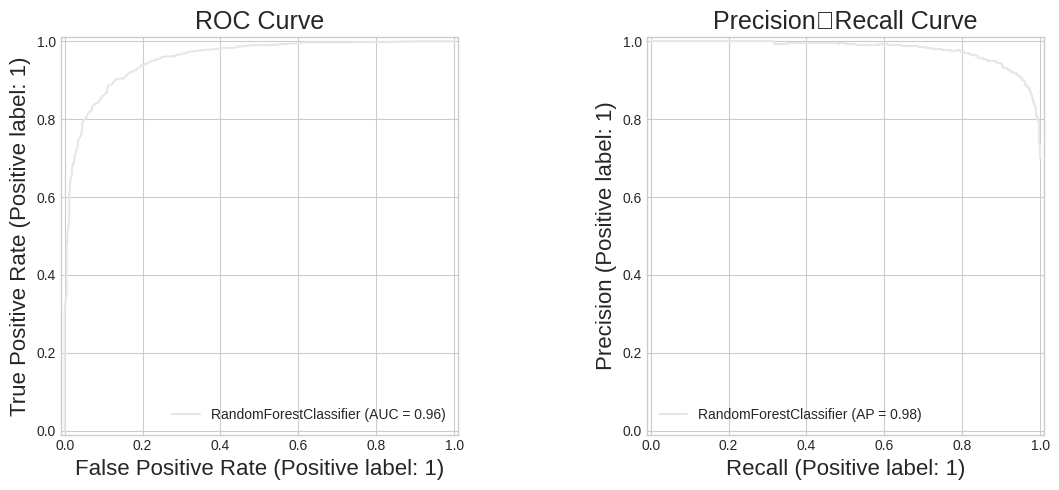


Feature importances:


logP     1.253121e-01
MolWt    6.850430e-02
TPSA     2.520087e-02
Rings    2.503836e-02
RotB     2.141653e-02
             ...     
285      2.097056e-06
1553     1.766999e-06
48       3.036871e-07
1596     1.479248e-07
830      0.000000e+00
Length: 2055, dtype: float64

{'accuracy': 0.8952905811623246,
 'precision': np.float64(0.9053778080326753),
 'recall': np.float64(0.95),
 'f1': np.float64(0.9271523178807947),
 'roc_auc': np.float64(0.9551516059443911),
 'pr_auc': np.float64(0.9796794296192601),
 'mcc': np.float64(0.7441421873026861)}

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    "n_estimators": [200, 400],
    "max_depth":   [None, 20],
    "min_samples_leaf": [1, 5]
}
gs = GridSearchCV(
        RandomForestClassifier(n_jobs=1, random_state=0),
        param_grid, cv=3, scoring="f1", n_jobs=-1, verbose=1)
gs.fit(Xtrain_dict["FP_ECFP4+DESC"], y_train)
print("Best params :", gs.best_params_)
best_rf = gs.best_estimator_
evaluate_model(best_rf,
               Xtest_dict["FP_ECFP4+DESC"],
               y_test,
               feature_names=Xtrain_dict["FP_ECFP4+DESC"].columns,
               plot_curves=True)


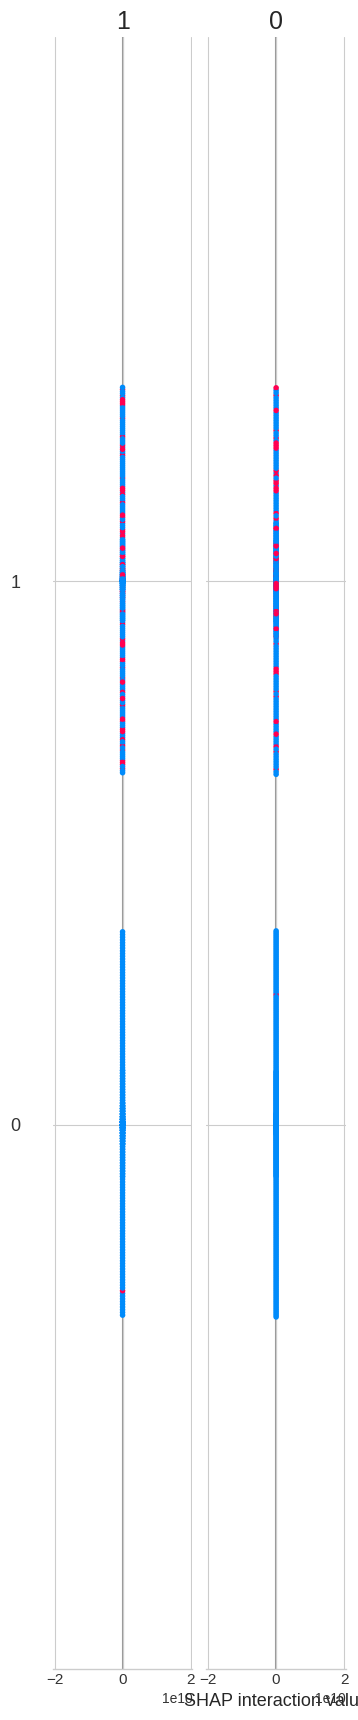

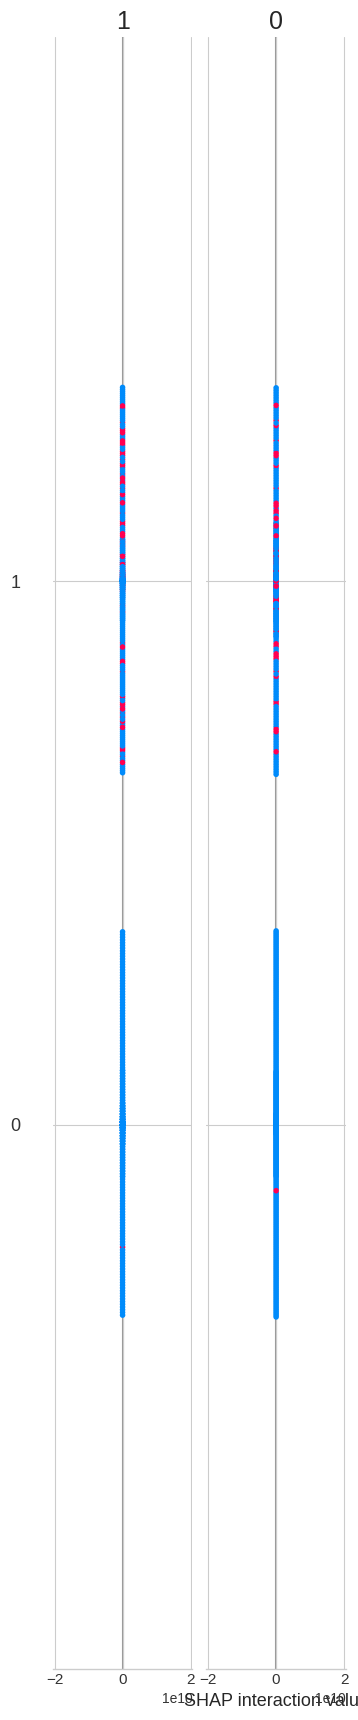

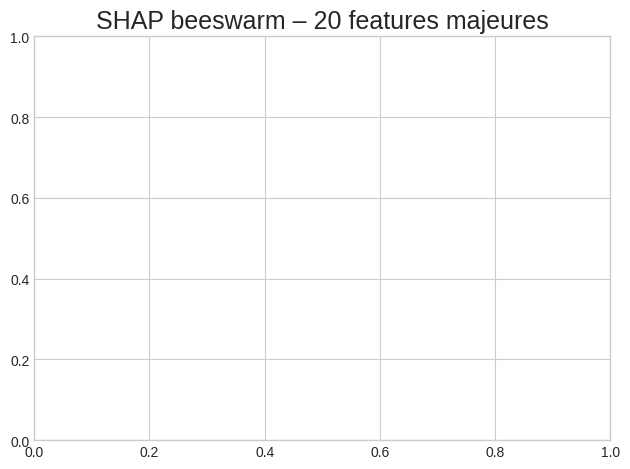

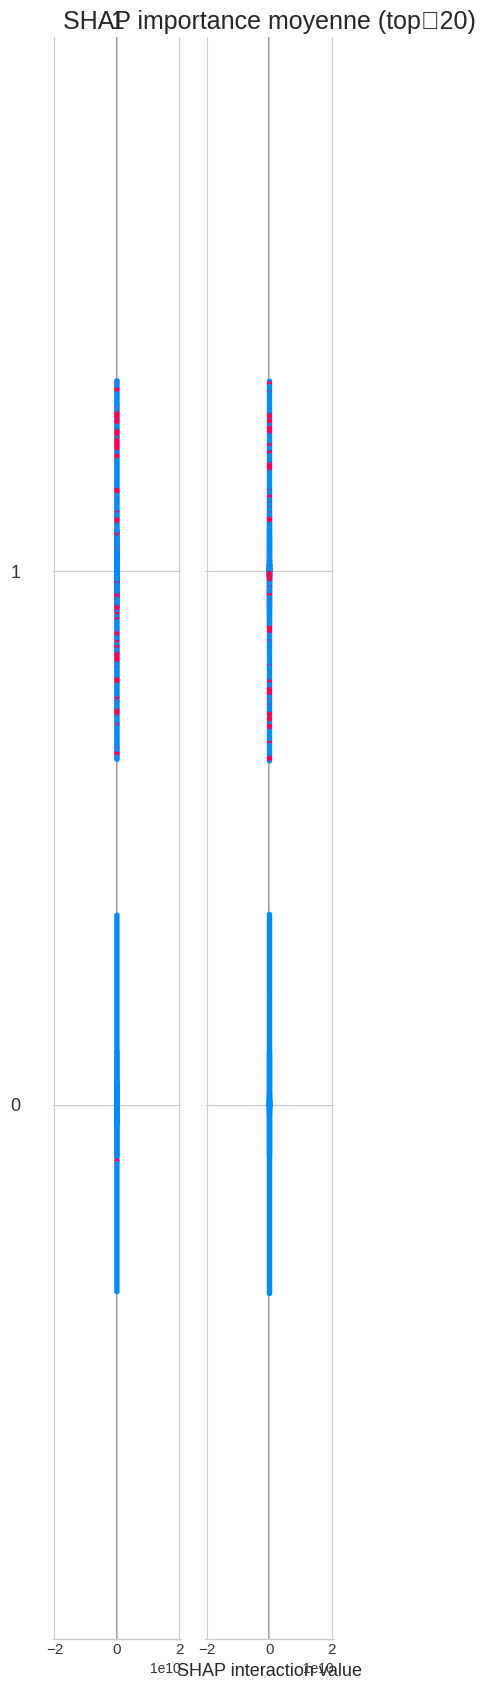

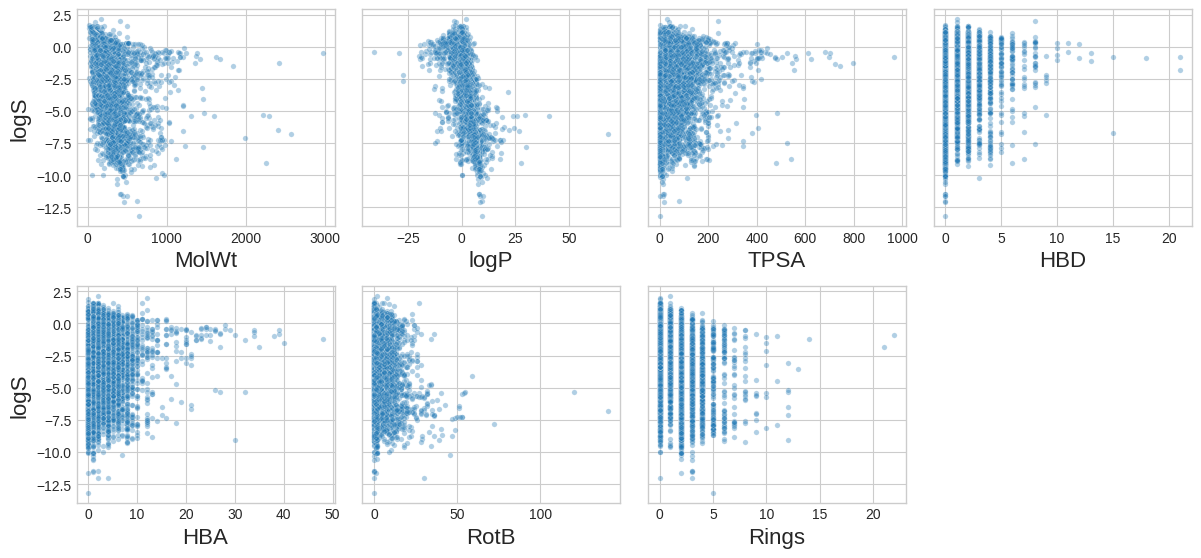

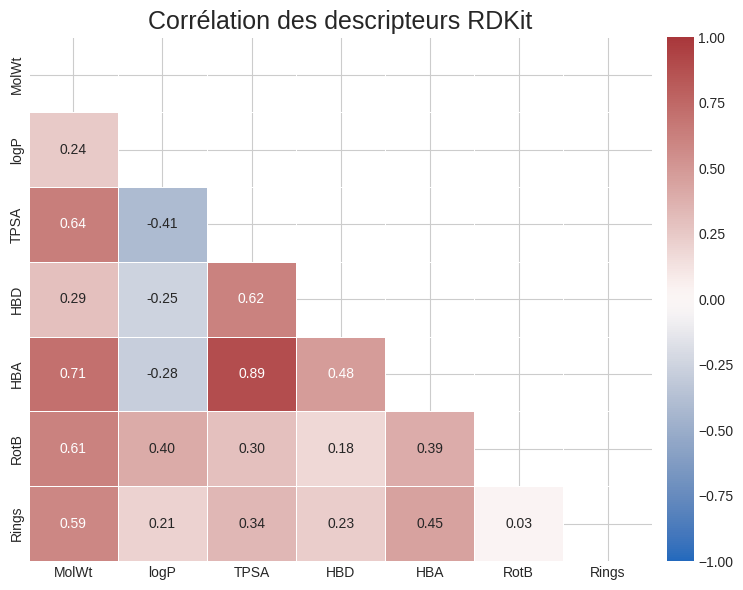

In [6]:
# %% [code] — SHAP propres (20 features les + importantes)
import shap, seaborn as sns, matplotlib.pyplot as plt, numpy as np

best_fs = "FP_ECFP4+DESC"
X_sample = Xtest_dict[best_fs].sample(n=300, random_state=1)

explainer = shap.TreeExplainer(best_rf)                 # best_rf = ton RF optimisé
phi       = explainer.shap_values(X_sample, check_additivity=False)
phi       = phi[1] if isinstance(phi, list) else phi    # classe « soluble » ou array direct

# Beeswarm (20 variables maxi)
shap.summary_plot(
    phi,
    X_sample,
    feature_names=X_sample.columns.astype(str),
    max_display=20,              # ← limite à 20
    plot_size=(6,4)
)

# Barplot importance moyenne (top‑20)
shap.summary_plot(
    phi,
    X_sample,
    feature_names=X_sample.columns.astype(str),
    plot_type="bar",
    max_display=20,
    plot_size=(6,4)
)
plt.title("SHAP beeswarm – 20 features majeures")
plt.tight_layout()
plt.show()

# Barplot importance moyenne
shap.summary_plot(
    phi, X_sample,
    feature_names=X_sample.columns.astype(str),
    plot_type="bar", max_display=20, show=False, plot_size=(6,4)
)
plt.title("SHAP importance moyenne (top‑20)")
plt.tight_layout(); plt.show()

## -----------------------------------------------------------
## 2) Scatter‑plots (descripteurs RDKit vs logS)

desc_df = pd.DataFrame(
    train_df["Drug"].map(lambda s: rdkit_desc_vec(process_smiles(s))).tolist(),
    columns=list(RDKIT_DESCRIPTORS.keys()),
    index=train_df.index
).astype(float)
desc_df["logS"] = train_df["Y"].values

fig, axs = plt.subplots(3, 4, figsize=(12, 8), sharey=True)
axs = axs.flatten()
for i, feat in enumerate(RDKIT_DESCRIPTORS.keys()):
    sns.scatterplot(ax=axs[i], x=desc_df[feat], y=desc_df["logS"],
                    s=15, alpha=.35, color="tab:blue")
    axs[i].set_xlabel(feat)
    if i % 4 == 0:
        axs[i].set_ylabel("logS")
for j in range(len(RDKIT_DESCRIPTORS), len(axs)):
    fig.delaxes(axs[j])
plt.tight_layout(); plt.show()

## -----------------------------------------------------------
## 3) Heatmap de corrélations des descripteurs
corr = desc_df.drop(columns="logS").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="vlag", vmin=-1, vmax=1,
            linewidths=.5, cbar_kws={"pad":0.02})
plt.title("Corrélation des descripteurs RDKit")
plt.tight_layout(); plt.show()

